In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(8807, 12)


In [5]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
# Fill missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Drop rows with missing date_added and duration
df.dropna(subset=['date_added', 'duration'], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [7]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(8794, 12)


In [10]:
print("Final Dataset Information")
print("-------------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Final Dataset Information
-------------------------
Rows: 8794
Columns: 12


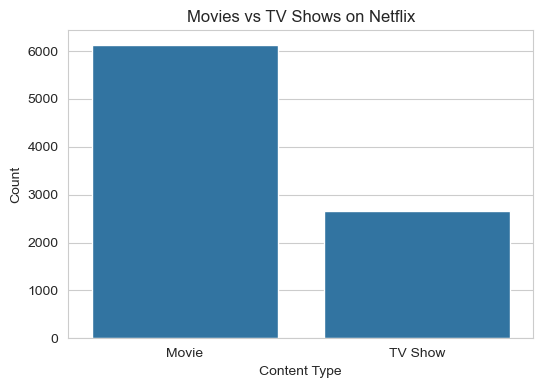

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

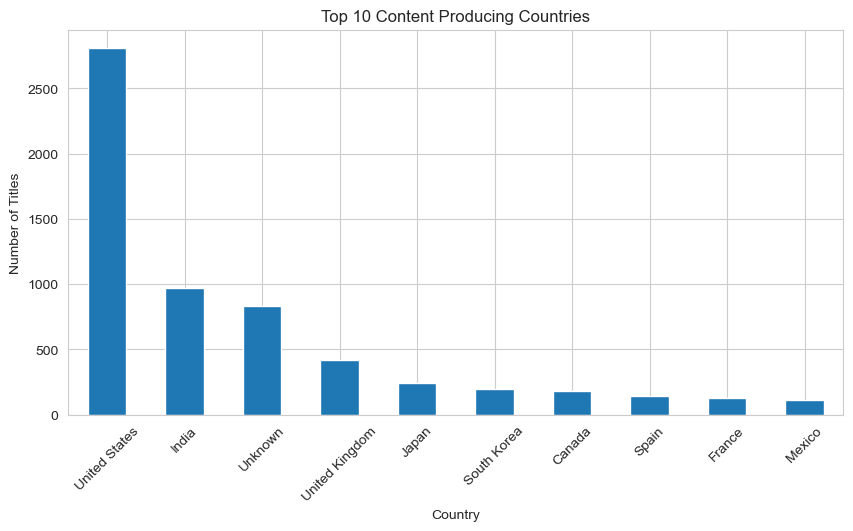

In [12]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

In [14]:
# Remove extra spaces
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

# Extract year
df['year_added'] = df['date_added'].dt.year

print(df['year_added'].head())

0    2021
1    2021
2    2021
3    2021
4    2021
Name: year_added, dtype: int32


In [15]:
print("Missing dates after conversion:")
print(df['year_added'].isnull().sum())

Missing dates after conversion:
0


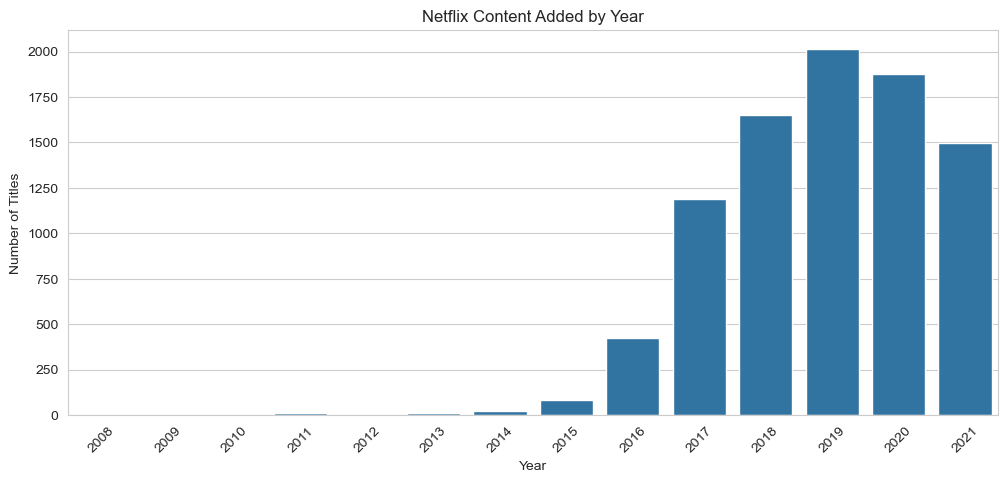

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='year_added',
    order=sorted(df['year_added'].unique())
)

plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

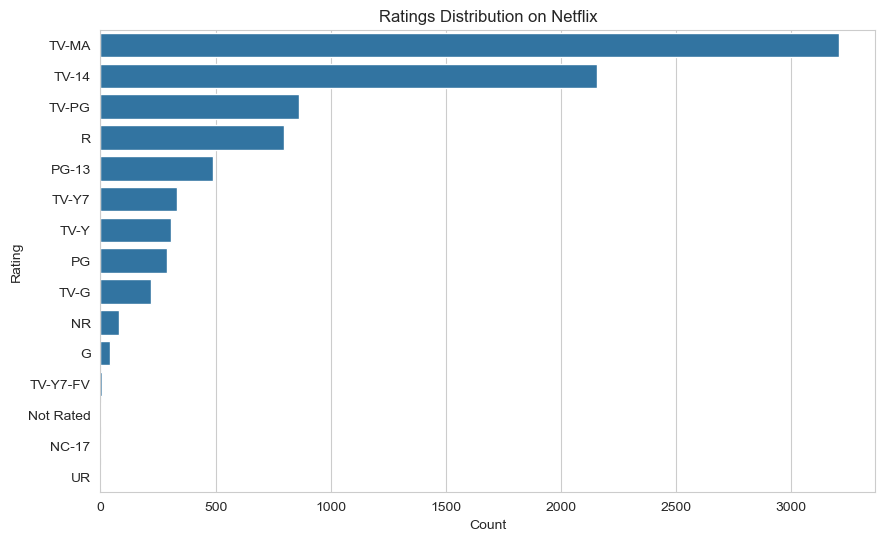

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)

plt.title('Ratings Distribution on Netflix')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

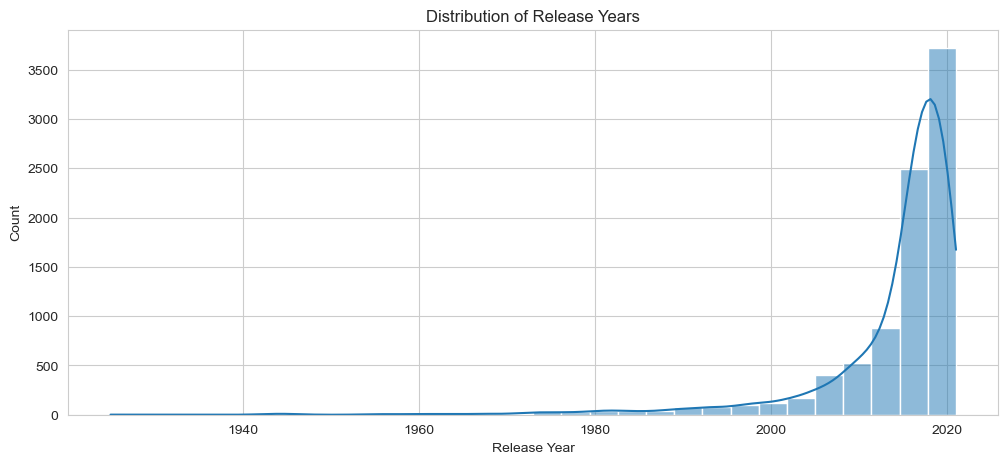

In [18]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['release_year'],
    bins=30,
    kde=True
)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

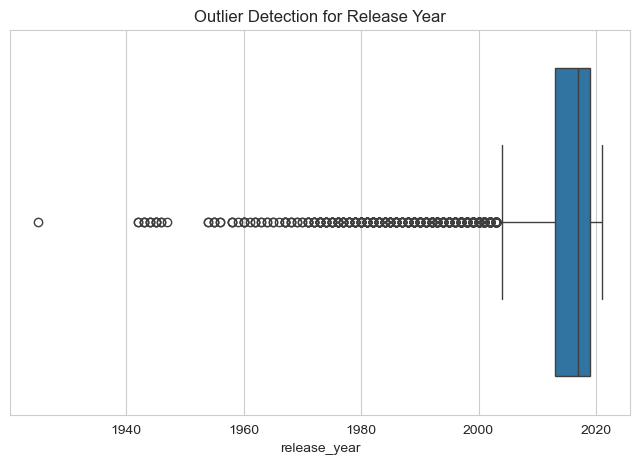

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['release_year'])

plt.title('Outlier Detection for Release Year')

plt.show()

In [20]:
df.describe()

,date_added,release_year,year_added
count,8794,8794.000000,8794.000000
mean,2019-05-17 13:29:44.034568960,2014.183534,2018.872754
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.823527,1.573789


In [21]:
df.to_csv("cleaned_netflix_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
